In [3]:
import os

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.model_selection import train_test_split

In [4]:
from mtflearn.utils import normalize_image
from symmlearn.lattice import (
    PlaneGroup,
    PGLattice,
    PGImage,
    WyckoffStructure
)
from symmlearn.utils import check_random_state
from stemplot.utils import plot_bar

In [5]:
# function to load excel file
# load into pandas dataframe
def load_df():
    current_folder = os.getcwd()
    parent = os.path.dirname(current_folder)
    data_path = parent+"\\data\\accumulated seeds\\seeds.xlsx"
    df = pd.read_excel(data_path, header=None)
    df.columns = ['PG_number', 'Seeds', 'Structures', 'Image_size', 'Label']
    return df

In [6]:
# get 3D numpy array with a shape of (8, H, W)
def get_img_data(pg_num, seed, structure, image_size):
    rng = np.random.RandomState(seed) ## this must be a RandomState
    ws = WyckoffStructure(pg_num=pg_num, structure_letters=structure)
    struct_dict = ws.to_structure_dict(seed=rng)
    pg = PlaneGroup(plane_group=pg_num)
    lattice = pg.generate_lattice(struct_dict, size=image_size, seed=rng, max_samples=5, angle_deg=0, sigma_method='min',verbose=False)
    pgi = lattice.get_image(image_size=image_size, sigma_map=None, seed=rng)
    pgi.compute_symm_maps(patch_size=None, n_max=20, return_angle=True, crop=False)
    return np.array([pgi.img,pgi.ref_map,pgi.sin_map,pgi.cos_map,pgi.rot_maps[0],pgi.rot_maps[1],pgi.rot_maps[2],pgi.rot_maps[3]])

# given a pg number, random select samples within this group 
def select_samples(df, pg_num, seed=None, samples=100):
    rng = check_random_state(seed)
    select_rows = df[df['Label'] == pg_num]
    counts = len(select_rows)
    if counts>=samples:
        sample_rows = select_rows.sample(n=samples, random_state=rng)
    else:
        print(f'Number of samples: {samples} is larger than number of select PG Number seeds: {counts}')
        sample_rows = select_rows
    return sample_rows

def generate_data_in_batches(h5_path, train_seeds, val_seeds, test_seeds, 
                            train_lbs, val_lbs, test_lbs, batch_size=20, use_tqdm=True):
    # Verify that the labels stored in the file match the input labels
    with h5py.File(h5_path, 'r') as f:
        saved_train_lbs = f['train']['labels'][:]
        saved_val_lbs = f['val']['labels'][:]
        saved_test_lbs = f['test']['labels'][:]
        
        # Assert that labels match
        assert np.array_equal(saved_train_lbs, train_lbs), "Train labels mismatch!"
        assert np.array_equal(saved_val_lbs, val_lbs), "Validation labels mismatch!"
        assert np.array_equal(saved_test_lbs, test_lbs), "Test labels mismatch!"
    
    # Process training set
    print("Generating training data...")
    _process_seeds_batch(h5_path, train_seeds, 'train', batch_size, use_tqdm)
    
    # Process validation set
    print("Generating validation data...")
    _process_seeds_batch(h5_path, val_seeds, 'val', batch_size, use_tqdm)
    
    # Process test set
    print("Generating test data...")
    _process_seeds_batch(h5_path, test_seeds, 'test', batch_size, use_tqdm)
    
    print(f"Data generation complete. Saved to {h5_path}")

def _process_seeds_batch(h5_path, seeds, dataset_name, batch_size, use_tqdm):
    n_samples = len(seeds)
    total_batches = (n_samples + batch_size - 1) // batch_size
    
    # Create iterator with optional progress bar
    if use_tqdm:
        # Use explicit position and leave=False to prevent overlap
        batch_range = tqdm(
            range(0, n_samples, batch_size),
            desc=f"Processing {dataset_name} batches",
            total=total_batches,
            position=0,  # Explicitly set position
            leave=True   # Keep the bar after completion
        )
    else:
        batch_range = range(0, n_samples, batch_size)
    
    # Process seeds in batches
    for start_idx in batch_range:
        end_idx = min(start_idx + batch_size, n_samples)
        batch_seeds = seeds[start_idx:end_idx]
        
        # Generate data for the current batch
        batch_data = []
        for i, seed_row in enumerate(batch_seeds):
            try:
                # Unpack seed data
                pg_num, select_seed, structure, image_size, label = seed_row
                img_data = get_img_data(
                    pg_num=int(pg_num),
                    seed=int(select_seed),
                    structure=structure,
                    image_size=int(image_size)
                )
                batch_data.append(img_data)
            except Exception as e:
                print(f"Error generating data for {dataset_name} sample {start_idx + i}: {e}")
                # On error, fill with zeros
                batch_data.append(np.zeros((8, 512, 512), dtype=np.float32))
        
        # Write the batch data to the HDF5 file
        batch_data_array = np.array(batch_data).astype(np.float32)
        
        with h5py.File(h5_path, 'a') as f:
            f[f'{dataset_name}/data'][start_idx:end_idx] = batch_data_array
        
        # Explicitly release memory
        del batch_data, batch_data_array
        
        # Update tqdm description if needed
        if use_tqdm:
            batch_range.set_postfix({
                'samples': f"{start_idx+1}-{min(end_idx, n_samples)}",
                'dataset': dataset_name
            })
    
    # Close the progress bar explicitly if tqdm was used
    if use_tqdm:
        batch_range.close()

In [7]:
def train_val_test_split(data, labels, ratio=[0.8,0.1,0.1], seed=None, **kwargs):
    rng = check_random_state(seed)
    
    if len(data) != len(labels):
        raise ValueError('Length of data and labels must be same!')
    if sum(ratio) != 1:
        raise ValueError('Sum of ratio must be 1!')
    if len(ratio) not in [2,3]:
        raise ValueError('Ration must be [train, val, test] or [train, val].')
    if len(ratio) == 2:
        train_ratio, val_ratio = ratio
        X_train, X_val, y_train, y_val = train_test_split(data, labels, test_size=val_ratio, random_state=rng, **kwargs)
        return [X_train, X_val, y_train, y_val]
    else:
        train_ratio, val_ratio, test_ratio = ratio
        ## first split train and other:
        X_train, X_rest, y_train, y_rest = train_test_split(data, labels, test_size=val_ratio+test_ratio, random_state=rng, **kwargs)
        test_ratio /= (val_ratio+test_ratio)
        ## sencond split validation and test:
        X_val, X_test, y_val, y_test = train_test_split(X_rest, y_rest, test_size=test_ratio, random_state=rng, **kwargs)
        return [X_train, X_val, X_test, y_train, y_val, y_test]

def save_to_h5(filename, train_seeds, val_seeds, test_seeds, 
               train_lbs, val_lbs, test_lbs, image_size=512, **kwargs):
    current_folder = os.getcwd()
    parent = os.path.dirname(current_folder)
    data_path = parent + f"\\data\\training datasets\\{filename}"
    
    # Remove the file if it already exists
    if os.path.exists(data_path):
        os.remove(data_path)
    
    # Create HDF5 file and pre-allocate space
    with h5py.File(data_path, 'w') as f:
        # Training set
        train_group = f.create_group('train')
        n_train = len(train_seeds)
        train_group.create_dataset('data', shape=(n_train, 8, image_size, image_size), 
                                  dtype=np.float32, chunks=(1, 8, image_size, image_size))
        train_group.create_dataset('labels', shape=(n_train,), dtype=np.int64)
        train_group['labels'][:] = train_lbs.astype(np.int64)
        
        # Validation set
        val_group = f.create_group('val')
        n_val = len(val_seeds)
        val_group.create_dataset('data', shape=(n_val, 8, image_size, image_size), 
                                dtype=np.float32, chunks=(1, 8, image_size, image_size))
        val_group.create_dataset('labels', shape=(n_val,), dtype=np.int64)
        val_group['labels'][:] = val_lbs.astype(np.int64)
        
        # Test set
        test_group = f.create_group('test')
        n_test = len(test_seeds)
        test_group.create_dataset('data', shape=(n_test, 8, image_size, image_size), 
                                 dtype=np.float32, chunks=(1, 8, image_size, image_size))
        test_group.create_dataset('labels', shape=(n_test,), dtype=np.int64)
        test_group['labels'][:] = test_lbs.astype(np.int64)
    
    print(f"Created HDF5 file with space for {n_train} train, {n_val} val, {n_test} test samples")
    return data_path

In [9]:
# load excel file
typical_structures_df = load_df()

typical_structures_df

,PG_number,Seeds,Structures,Image_size,Label
0,10,2070323360,d,512,10
1,10,1123453553,d,512,10
2,10,996900380,d,512,10
3,10,433518366,d,512,10
4,10,5265305,d,512,10
...,...,...,...,...,...
20055,9,286828693,abceee,512,9
20056,9,493517424,abceee,512,9
20057,9,1867094614,abceee,512,9
20058,9,1743982861,abceee,512,9


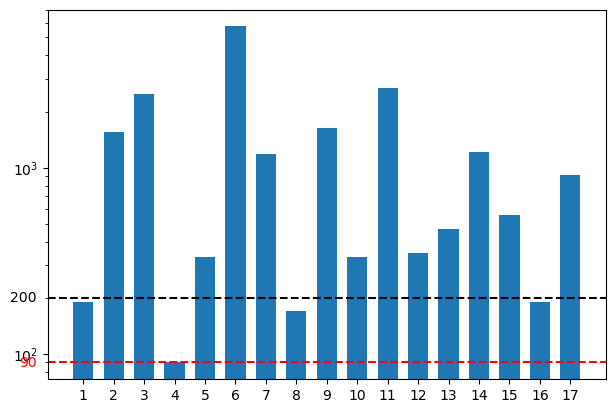

In [21]:
# counts plane groups and plot in barchart
unique_lbs, counts = np.unique(typical_structures_df['Label'].values, return_counts=True)

fig, ax = plt.subplots(figsize = (7.2, 4.8))
plot_bar(ax,data=counts,labels=unique_lbs)
min_count = counts.min()
ax.axhline(min_count, ls = '--', color = 'red')
ax.text(-0.02, min_count, f'{min_count}', 
        transform=ax.get_yaxis_transform(),
        color='red', ha='right', va='center')
ax.axhline(200, ls = '--', color = 'black')
ax.text(-0.02, 200, f'{200}', 
        transform=ax.get_yaxis_transform(),
        color='black', ha='right', va='center')
ax.set_yscale('log')

## Generate and save oblique system image data

In [10]:
rng = check_random_state(48)
pg_1_seeds = select_samples(typical_structures_df, pg_num=1, seed=rng, samples=200).values
pg_2_seeds = select_samples(typical_structures_df, pg_num=2, seed=rng, samples=200).values

pg_1_lbs = np.full((len(pg_1_seeds),), 1)
pg_2_lbs = np.full((len(pg_2_seeds),), 2)

oblique_seeds = np.vstack([pg_1_seeds, pg_2_seeds])
oblique_lbs = np.hstack([pg_1_lbs, pg_2_lbs])

# split train, valid, test seeds and lbs
train_seeds, val_seeds, test_seeds, train_lbs, val_lbs, test_lbs = train_val_test_split(
    oblique_seeds, oblique_lbs, ratio=[0.8, 0.1, 0.1], seed=rng, shuffle=True
)

# create h5 file
h5_path = save_to_h5(filename='oblique_system_dataset.h5', 
                     train_seeds=train_seeds, 
                     val_seeds=val_seeds, 
                     test_seeds=test_seeds, 
                     train_lbs=train_lbs, 
                     val_lbs=val_lbs, 
                     test_lbs=test_lbs, 
                     image_size=512)

# generate data in batch and save to .h5 file
generate_data_in_batches(h5_path=h5_path, 
                         train_seeds=train_seeds, 
                         val_seeds=val_seeds, 
                         test_seeds=test_seeds, 
                         train_lbs=train_lbs, 
                         val_lbs=val_lbs, 
                         test_lbs=test_lbs, 
                         batch_size=100, 
                         use_tqdm=True)

Number of samples: 200 is larger than number of select PG Number seeds: 190
Created HDF5 file with space for 312 train, 39 val, 39 test samples
Generating training data...


Processing train batches: 100%|██████████████████████████| 4/4 [06:12<00:00, 93.22s/it, samples=301-312, dataset=train]


Generating validation data...


Processing val batches: 100%|█████████████████████████████████| 1/1 [00:45<00:00, 45.41s/it, samples=1-39, dataset=val]


Generating test data...


Processing test batches: 100%|███████████████████████████████| 1/1 [00:45<00:00, 45.30s/it, samples=1-39, dataset=test]

Data generation complete. Saved to D:\work\symmlearn\data\training datasets\oblique_system_dataset.h5


## Generate and save rectangle system image data

In [12]:
rng = check_random_state(48)
pg_3_seeds = select_samples(typical_structures_df, pg_num=3, seed=rng, samples=200).values
pg_4_seeds = select_samples(typical_structures_df, pg_num=4, seed=rng, samples=200).values
pg_5_seeds = select_samples(typical_structures_df, pg_num=5, seed=rng, samples=200).values
pg_6_seeds = select_samples(typical_structures_df, pg_num=6, seed=rng, samples=200).values
pg_7_seeds = select_samples(typical_structures_df, pg_num=7, seed=rng, samples=200).values
pg_8_seeds = select_samples(typical_structures_df, pg_num=8, seed=rng, samples=200).values
pg_9_seeds = select_samples(typical_structures_df, pg_num=9, seed=rng, samples=200).values

pg_3_lbs = np.full((len(pg_3_seeds),), 3)
pg_4_lbs = np.full((len(pg_4_seeds),), 4)
pg_5_lbs = np.full((len(pg_5_seeds),), 5)
pg_6_lbs = np.full((len(pg_6_seeds),), 6)
pg_7_lbs = np.full((len(pg_7_seeds),), 7)
pg_8_lbs = np.full((len(pg_8_seeds),), 8)
pg_9_lbs = np.full((len(pg_9_seeds),), 9)

rect_seeds = np.vstack([pg_3_seeds, pg_4_seeds, pg_5_seeds, pg_6_seeds, pg_7_seeds, pg_8_seeds, pg_9_seeds])
rect_lbs = np.hstack([pg_3_lbs, pg_4_lbs, pg_5_lbs, pg_6_lbs, pg_7_lbs, pg_8_lbs, pg_9_lbs])

# split train, valid, test seeds and lbs
train_seeds, val_seeds, test_seeds, train_lbs, val_lbs, test_lbs = train_val_test_split(
    rect_seeds, rect_lbs, ratio=[0.8, 0.1, 0.1], seed=rng, shuffle=True
)

# create h5 file
h5_path = save_to_h5(filename='rect_system_dataset.h5', 
                     train_seeds=train_seeds, 
                     val_seeds=val_seeds, 
                     test_seeds=test_seeds, 
                     train_lbs=train_lbs, 
                     val_lbs=val_lbs, 
                     test_lbs=test_lbs, 
                     image_size=512)

# generate data in batch and save to .h5 file
generate_data_in_batches(h5_path=h5_path, 
                         train_seeds=train_seeds, 
                         val_seeds=val_seeds, 
                         test_seeds=test_seeds, 
                         train_lbs=train_lbs, 
                         val_lbs=val_lbs, 
                         test_lbs=test_lbs, 
                         batch_size=100, 
                         use_tqdm=True)

Number of samples: 200 is larger than number of select PG Number seeds: 90
Number of samples: 200 is larger than number of select PG Number seeds: 170
Created HDF5 file with space for 1008 train, 126 val, 126 test samples
Generating training data...


Processing train batches: 100%|█████████████████████| 11/11 [19:39<00:00, 107.26s/it, samples=1001-1008, dataset=train]


Generating validation data...


Processing val batches: 100%|██████████████████████████████| 2/2 [02:31<00:00, 75.63s/it, samples=101-126, dataset=val]


Generating test data...


Processing test batches: 100%|████████████████████████████| 2/2 [02:28<00:00, 74.07s/it, samples=101-126, dataset=test]

Data generation complete. Saved to D:\work\symmlearn\data\training datasets\rect_system_dataset.h5


## Generate and save square system image data

In [13]:
rng = check_random_state(48)
pg_10_seeds = select_samples(typical_structures_df, pg_num=10, seed=rng, samples=200).values
pg_11_seeds = select_samples(typical_structures_df, pg_num=11, seed=rng, samples=200).values
pg_12_seeds = select_samples(typical_structures_df, pg_num=12, seed=rng, samples=200).values

pg_10_lbs = np.full((len(pg_10_seeds),), 10)
pg_11_lbs = np.full((len(pg_11_seeds),), 11)
pg_12_lbs = np.full((len(pg_12_seeds),), 12)

square_seeds = np.vstack([pg_10_seeds, pg_11_seeds, pg_12_seeds])
square_lbs = np.hstack([pg_10_lbs, pg_11_lbs, pg_12_lbs])

# split train, valid, test seeds and lbs
train_seeds, val_seeds, test_seeds, train_lbs, val_lbs, test_lbs = train_val_test_split(
    square_seeds, square_lbs, ratio=[0.8, 0.1, 0.1], seed=rng, shuffle=True
)

# create h5 file
h5_path = save_to_h5(filename='square_system_dataset.h5', 
                     train_seeds=train_seeds, 
                     val_seeds=val_seeds, 
                     test_seeds=test_seeds, 
                     train_lbs=train_lbs, 
                     val_lbs=val_lbs, 
                     test_lbs=test_lbs, 
                     image_size=512)

# generate data in batch and save to .h5 file
generate_data_in_batches(h5_path=h5_path, 
                         train_seeds=train_seeds, 
                         val_seeds=val_seeds, 
                         test_seeds=test_seeds, 
                         train_lbs=train_lbs, 
                         val_lbs=val_lbs, 
                         test_lbs=test_lbs, 
                         batch_size=100, 
                         use_tqdm=True)

Created HDF5 file with space for 480 train, 60 val, 60 test samples
Generating training data...


Processing train batches: 100%|█████████████████████████| 5/5 [08:44<00:00, 104.95s/it, samples=401-480, dataset=train]


Generating validation data...


Processing val batches: 100%|█████████████████████████████████| 1/1 [01:02<00:00, 62.68s/it, samples=1-60, dataset=val]


Generating test data...


Processing test batches: 100%|███████████████████████████████| 1/1 [01:08<00:00, 68.39s/it, samples=1-60, dataset=test]

Data generation complete. Saved to D:\work\symmlearn\data\training datasets\square_system_dataset.h5


## Generate and save hexagonal system image data

In [14]:
rng = check_random_state(48)
pg_13_seeds = select_samples(typical_structures_df, pg_num=13, seed=rng, samples=200).values
pg_14_seeds = select_samples(typical_structures_df, pg_num=14, seed=rng, samples=200).values
pg_15_seeds = select_samples(typical_structures_df, pg_num=15, seed=rng, samples=200).values
pg_16_seeds = select_samples(typical_structures_df, pg_num=16, seed=rng, samples=200).values
pg_17_seeds = select_samples(typical_structures_df, pg_num=17, seed=rng, samples=200).values

pg_13_lbs = np.full((len(pg_13_seeds),), 13)
pg_14_lbs = np.full((len(pg_14_seeds),), 14)
pg_15_lbs = np.full((len(pg_15_seeds),), 15)
pg_16_lbs = np.full((len(pg_16_seeds),), 16)
pg_17_lbs = np.full((len(pg_17_seeds),), 17)

hex_seeds = np.vstack([pg_13_seeds, pg_14_seeds, pg_15_seeds, pg_16_seeds, pg_17_seeds])
hex_lbs = np.hstack([pg_13_lbs, pg_14_lbs, pg_15_lbs, pg_16_lbs, pg_17_lbs])

# split train, valid, test seeds and lbs
train_seeds, val_seeds, test_seeds, train_lbs, val_lbs, test_lbs = train_val_test_split(
    hex_seeds, hex_lbs, ratio=[0.8, 0.1, 0.1], seed=rng, shuffle=True
)

# create h5 file
h5_path = save_to_h5(filename='hex_system_dataset.h5', 
                     train_seeds=train_seeds, 
                     val_seeds=val_seeds, 
                     test_seeds=test_seeds, 
                     train_lbs=train_lbs, 
                     val_lbs=val_lbs, 
                     test_lbs=test_lbs, 
                     image_size=512)

# generate data in batch and save to .h5 file
generate_data_in_batches(h5_path=h5_path, 
                         train_seeds=train_seeds, 
                         val_seeds=val_seeds, 
                         test_seeds=test_seeds, 
                         train_lbs=train_lbs, 
                         val_lbs=val_lbs, 
                         test_lbs=test_lbs, 
                         batch_size=100, 
                         use_tqdm=True)

Number of samples: 200 is larger than number of select PG Number seeds: 190
Created HDF5 file with space for 792 train, 99 val, 99 test samples
Generating training data...


Processing train batches: 100%|█████████████████████████| 8/8 [16:24<00:00, 123.06s/it, samples=701-792, dataset=train]


Generating validation data...


Processing val batches: 100%|████████████████████████████████| 1/1 [02:05<00:00, 125.44s/it, samples=1-99, dataset=val]


Generating test data...


Processing test batches: 100%|██████████████████████████████| 1/1 [01:58<00:00, 118.58s/it, samples=1-99, dataset=test]

Data generation complete. Saved to D:\work\symmlearn\data\training datasets\hex_system_dataset.h5
